In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [51]:
# Now let use see why linear regression fails for Logisic REGERESSION to begin with
# y^ = w.x  + b
# y^​∈(−∞,∞)

In [52]:
# We have literally nothing at this point here , no mechanism to classify the points into groups.
# Also our current line is not a classifying one what it does is try to fit all the points closer to the 
# As we know in Linear Regression we try to minimize the points by building a generalize model having no systematic
# error and only random error minimizing loss using MSE.

In [53]:
# What we want is some sort of probability where we can have two probabilities for a point 
# One for it belonging to +ve class and other in -ve class (Assuming we are doing Binary Classification)


In [54]:
df = pd.DataFrame({
    'size' : np.array([1,2,3,5,6,8]),
    'label' : np.array([0,0,0,1,1,1])
})

In [55]:
class LR:
    def __init__(self):
        self.coef = None
        self.intercept = None

    def fit(self,X,y):
        # Convert X to a 2D array if it is 1D
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X = np.insert(X,0,1,axis=1)
        W = np.linalg.inv(np.dot(np.transpose(X),X)).dot(np.transpose(X)).dot(y)

        self.coef = W[1:]
        self.intercept = W[:1]

    def predict(self,X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.dot(X,self.coef) + self.intercept

In [56]:
test_df = pd.DataFrame({'size_sample' : np.array([-2,0,1,4,8,12,20])})

In [57]:
model = LR()
model.fit(df['size'].values,df['label'].values)

In [59]:
test_df['predictions'] = model.predict(test_df['size_sample'].values)

In [60]:
test_df

,size_sample,predictions
0,-2,-0.650718
1,0,-0.277512
2,1,-0.090909
3,4,0.468900
4,8,1.215311
5,12,1.961722
6,20,3.454545


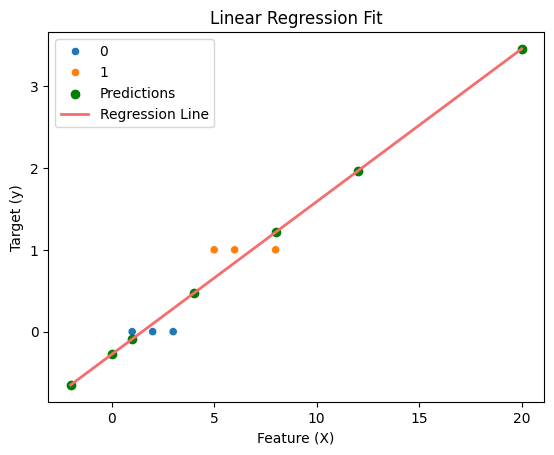

In [73]:
# Plot the regression line

X_line = np.linspace(-2,20,300)
y_line = model.predict(X_line)

sns.scatterplot(data = df,x='size',y='label',hue='label')
plt.scatter(
    test_df["size_sample"],
    test_df["predictions"],
    color="green",
    label="Predictions"
)
plt.plot(X_line, y_line, color="#F76C6C", linewidth=2, label="Regression Line")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [75]:
# Look closely , our line wants to touch points not seperate them.
# Cause that's the reason it was designed to begin with nothing concerned with probabilites and classification
# It has no knowledge of labels at all

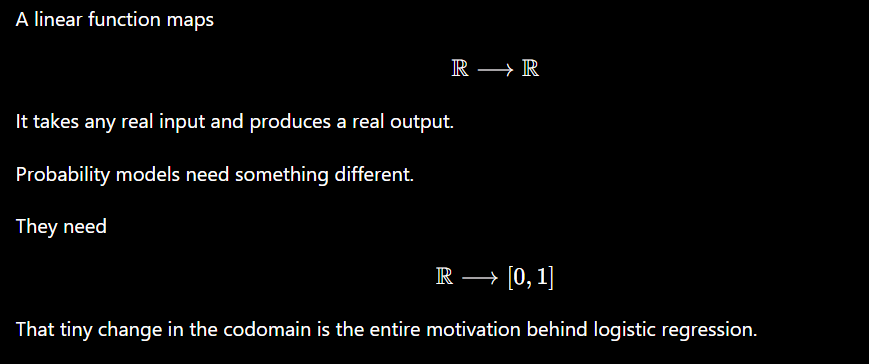

In [ ]:
""" 
    Linear Regression minimizes squared error and therefore learns a linear function over the real numbers. 
Because a linear function is unbounded, its predictions are not guaranteed to lie within the interval [0,1].
Consequently, although some predictions may resemble probabilities, the model provides no mathematical guarantee 
that its outputs are valid probabilities.
"""

In [ ]:
# What our requirement 
#  > We need probability not a score z
#  > We need it in the range [0,1] axiom
#  > We can use our linear function but how ?
#  > If scores are are suppose 2 and 5 for tumor A and B respectively :  then their transformed probabilites function must be f(5)>f(2)
#  > Graph is monotonically incresaing and looks like : 
""" 
              1 |              ______
                |            /
                |           /
            0.5 |----------/
                |         /
                |        /
              0 |    ___/
"""
#   > Large values let's say 20 are close to 1 should be classifiying greatly and having a value of closer to 1 
#   > IF z = 0 : ---> No preference
#                   This immediately gives us a decision rule:

                # z>0 → probability > 0.5
                # z<0 → probability < 0.5

# What we want is : 
#     Input x
#       │
#       ▼
# Linear Model
# z = wx+b
#       │
#       ▼
#  ?????????
#       │
#       ▼
# Probability

""" 
| Requirement                       | Reason                                  |
| --------------------------------- | --------------------------------------- |
| Output is always in ((0,1))       | Valid probabilities                     |
| Monotonically increasing          | Preserve ranking of scores              |
| Smooth and differentiable         | Gradient descent needs gradients        |
| (f(0)=0.5)                        | Zero score means no preference          |
| Approaches 0 and 1 asymptotically | Never predicts impossible probabilities |

"""

In [ ]:
# Why not step function ? 
# Gradient is 0 step is teleporting
""" 
Graph looks like : 
1 |_________
  |
  |
0 |_________
"""

' '